In [1]:
!git clone https://github.com/sartajbhuvaji/Brain-Tumor-Classification-DataSet.git

Cloning into 'Brain-Tumor-Classification-DataSet'...
remote: Enumerating objects: 3039, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 3039 (delta 0), reused 0 (delta 0), pack-reused 3033 (from 1)
Receiving objects: 100% (3039/3039), 79.24 MiB | 22.61 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Updating files: 100% (3264/3264), done.


In [2]:
!ls Brain-Tumor-Classification-DataSet/Training

glioma_tumor  meningioma_tumor	no_tumor  pituitary_tumor


In [3]:
import os
import shutil
import random

base_path = "Brain-Tumor-Classification-DataSet/Training"
binary_path = "binary_dataset"

os.makedirs(binary_path + "/tumor", exist_ok=True)
os.makedirs(binary_path + "/no", exist_ok=True)

# Collect tumor images
tumor_folders = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor"]
tumor_images = []

for folder in tumor_folders:
    folder_path = os.path.join(base_path, folder)
    tumor_images += [os.path.join(folder_path, img) for img in os.listdir(folder_path)]

# Select 250 tumor images
selected_tumor = random.sample(tumor_images, 250)

for img_path in selected_tumor:
    shutil.copy(img_path, binary_path + "/tumor")

# Select 250 no_tumor images
no_path = os.path.join(base_path, "no_tumor")
selected_no = random.sample(os.listdir(no_path), 250)

for img in selected_no:
    shutil.copy(os.path.join(no_path, img), binary_path + "/no")

print("Binary dataset with 500 images created successfully!")

Binary dataset with 500 images created successfully!


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3
)

train_data = datagen.flow_from_directory(
    "binary_dataset",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "binary_dataset",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 350 images belonging to 2 classes.
Found 150 images belonging to 2 classes.


In [6]:
model = Sequential()

# Convolution Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

# Convolution Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Convolution Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Fully Connected
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 577ms/step - accuracy: 0.4886 - loss: 0.7324 - val_accuracy: 0.5000 - val_loss: 0.6550
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.6629 - loss: 0.6186 - val_accuracy: 0.8200 - val_loss: 0.4861
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.8000 - loss: 0.4939 - val_accuracy: 0.8333 - val_loss: 0.4030
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.8657 - loss: 0.3862 - val_accuracy: 0.8333 - val_loss: 0.3654
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.8371 - loss: 0.3776 - val_accuracy: 0.7867 - val_loss: 0.4555
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.9114 - loss: 0.2413 - val_accuracy: 0.8933 - val_loss: 0.3074
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.9400 - loss: 0.2109 - val_accuracy: 0.7867 - val_loss: 0.4134
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.9286 - loss: 0.2012 - val_accuracy: 0.860

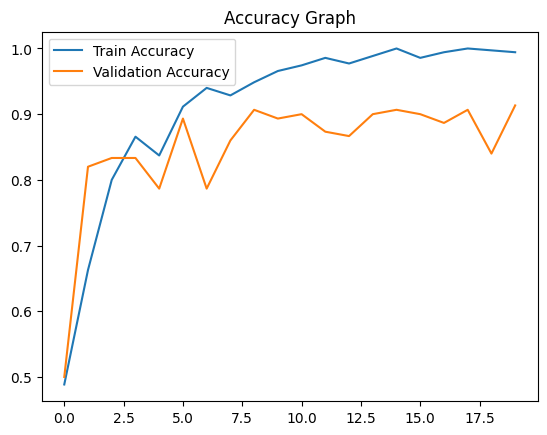

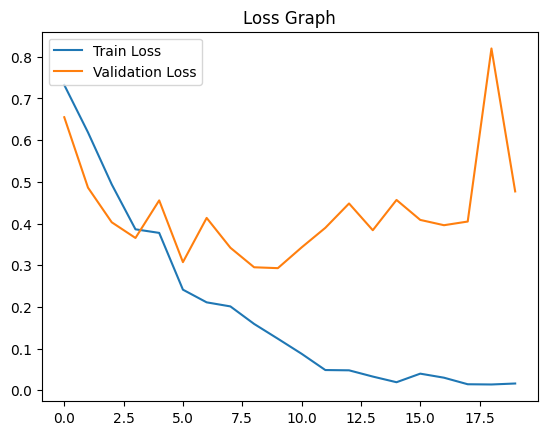

In [9]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

In [10]:
val_data.reset()
predictions = model.predict(val_data)
predicted_classes = np.round(predictions)

cm = confusion_matrix(val_data.classes, predicted_classes)
print("Confusion Matrix:\n", cm)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step
Confusion Matrix:
 [[28 47]
 [40 35]]


In [11]:
print(classification_report(val_data.classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.41      0.37      0.39        75
           1       0.43      0.47      0.45        75

    accuracy                           0.42       150
   macro avg       0.42      0.42      0.42       150
weighted avg       0.42      0.42      0.42       150



In [12]:
model.save("cnn_brain_tumor.h5")

In [13]:
from google.colab import files
files.download("cnn_brain_tumor.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
%%writefile cnn_model.py

import os
import shutil
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# -----------------------------
# 1. DATASET PREPARATION
# -----------------------------

# Clone dataset (if not already cloned)
os.system("git clone https://github.com/sartajbhuvaji/Brain-Tumor-Classification-DataSet.git")

base_path = "Brain-Tumor-Classification-DataSet/Training"
binary_path = "binary_dataset"

os.makedirs(binary_path + "/tumor", exist_ok=True)
os.makedirs(binary_path + "/no", exist_ok=True)

tumor_folders = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor"]
tumor_images = []

for folder in tumor_folders:
    folder_path = os.path.join(base_path, folder)
    tumor_images += [os.path.join(folder_path, img) for img in os.listdir(folder_path)]

selected_tumor = random.sample(tumor_images, 250)

for img_path in selected_tumor:
    shutil.copy(img_path, binary_path + "/tumor")

no_path = os.path.join(base_path, "no_tumor")
selected_no = random.sample(os.listdir(no_path), 250)

for img in selected_no:
    shutil.copy(os.path.join(no_path, img), binary_path + "/no")

print("Dataset prepared with 500 images")

# -----------------------------
# 2. DATA PREPROCESSING
# -----------------------------

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3
)

train_data = datagen.flow_from_directory(
    binary_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    binary_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# -----------------------------
# 3. BUILD CNN MODEL
# -----------------------------

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 4. TRAIN MODEL
# -----------------------------

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

# -----------------------------
# 5. EVALUATION
# -----------------------------

loss, accuracy = model.evaluate(val_data)
print("Validation Accuracy:", accuracy)

val_data.reset()
predictions = model.predict(val_data)
predicted_classes = np.round(predictions)

cm = confusion_matrix(val_data.classes, predicted_classes)
print("Confusion Matrix:\n", cm)

print("Classification Report:\n")
print(classification_report(val_data.classes, predicted_classes))

# -----------------------------
# 6. SAVE MODEL
# -----------------------------

model.save("cnn_brain_tumor.h5")
print("Model saved as cnn_brain_tumor.h5")

Writing cnn_model.py


In [15]:
from google.colab import files
files.download("cnn_model.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>